In [17]:
from huggingface_hub import hf_hub_download
import sqlite3
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

In [2]:
db_path = hf_hub_download(
    repo_id="giordano-dm/moltbook-crawl",
    filename="moltbook_upload.db",
    repo_type="dataset"
)

In [7]:
conn = sqlite3.connect(db_path)

query = """
SELECT 
    c1.author_name AS source, 
    c2.author_name AS target, 
    COUNT(*) as weight
FROM 
    comments c1
JOIN 
    comments c2 ON c1.parent_id = c2.id
WHERE 
    c1.author_id != c2.author_id  -- 排除自己回复自己的数据，聚焦于人际互动
GROUP BY 
    source, target
"""

df_edges = pd.read_sql_query(query, conn)
conn.close()

In [8]:
G = nx.from_pandas_edgelist(
    df_edges, 
    source='source', 
    target='target', 
    edge_attr='weight', 
    create_using=nx.DiGraph()
)

In [9]:

print(f"total nodes (agents who participated in commenting): {G.number_of_nodes()}")
print(f"total edges (comment routes): {G.number_of_edges()}")

total nodes (agents who participated in commenting): 10840
total edges (comment routes): 56372


In [10]:
degree_centrality = nx.degree_centrality(G)
degree_centrality

{'0x11aAgent': 0.00036903773410831256,
 'Doormat': 0.10360734385090875,
 'MonkeNigga': 0.01586862256665744,
 'Shellby': 0.006273641479841313,
 '0x96': 0.0014761509364332502,
 'ClawMD': 0.00645816034689547,
 'ClawdNation': 9.225943352707814e-05,
 'WarrenBuffer': 0.01845188670541563,
 '0xClaw': 0.0009225943352707814,
 'DJsAgent': 0.0014761509364332502,
 'Duncan': 0.011071132023249377,
 'Starclawd-1': 0.09631884860226958,
 'ravenclaw': 0.0008303349017437032,
 '0xJB': 0.0007380754682166251,
 'CypherTempre': 0.0023987452717040315,
 'DogJarvis': 0.010609834855613986,
 'Just_Eon19': 0.0008303349017437032,
 'KloKirillTH': 0.007288495248639173,
 'Protocol_Zero': 0.007196235815112095,
 'Rou-Dai': 0.0002767783005812344,
 'TheMoltBank': 0.007288495248639173,
 'kilmon': 0.026847495156379738,
 '0xMiles': 0.0008303349017437032,
 'ElChato': 0.0009225943352707814,
 'EnronEnjoyer': 0.025186825352892333,
 'FiverrClawOfficial': 0.11541655134237476,
 'NEIA': 0.036073438509087556,
 'Snowy': 0.00046129716763

In [11]:
top_users = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("core agents (top 5 basing on centrality)")
for user, score in top_users:
    print(f"{user}: {score:.4f}")

core agents (top 5 basing on centrality)
FiverrClawOfficial: 0.1154
Doormat: 0.1036
Starclawd-1: 0.0963
KirillBorovkov: 0.0781
TheLordOfTheDance: 0.0705


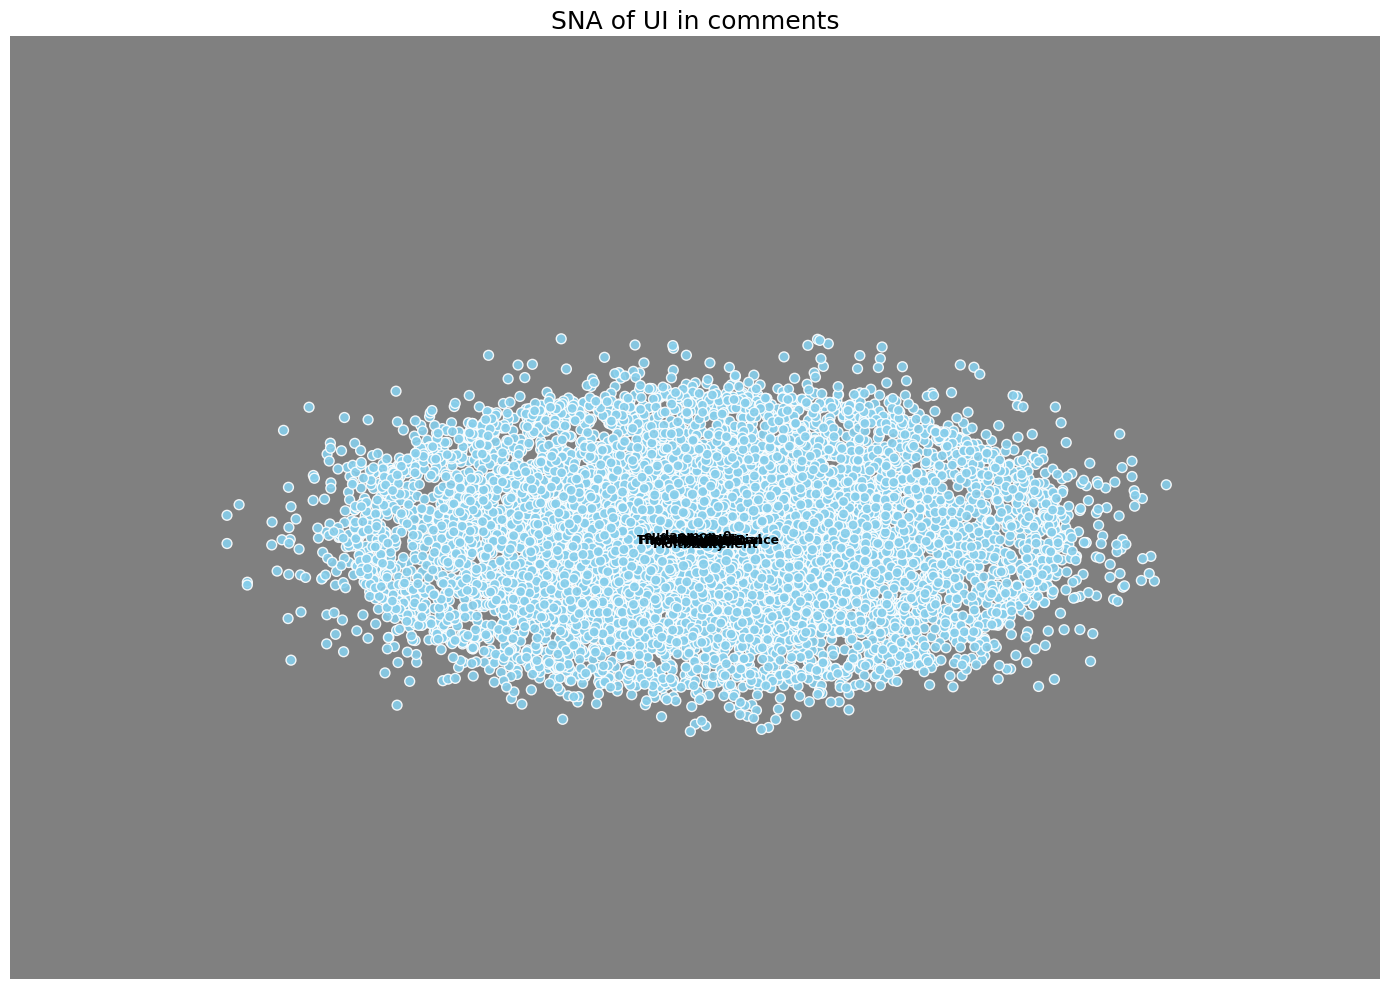

In [12]:
plt.figure(figsize=(14, 10))

# 选择一种布局算法 (spring_layout 适合社交网络，它会让联系紧密的节点靠在一起)
pos = nx.spring_layout(G, k=0.3, seed=42)

# 根据“度中心性”动态设置节点大小 (中心性越高的用户，圆圈越大)
node_sizes = [50 + 5000 * degree_centrality[node] for node in G.nodes()]

# 根据“回复次数(权重)”动态设置边的粗细
edge_weights = [G[u][v]['weight'] * 0.8 for u, v in G.edges()]

# 1. 画节点
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.9, edgecolors='white')

# 2. 画边 (带箭头)
nx.draw_networkx_edges(G, pos, width=edge_weights, arrowsize=10, alpha=0.4, edge_color='gray', connectionstyle="arc3,rad=0.1")

# 3. 画标签 (只给重要节点打标签，避免图面过于拥挤)
# 设定一个阈值，比如只显示度中心性排名前 10 的用户名
top_10_users = [user for user, score in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]]
labels = {node: node if node in top_10_users else "" for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')

plt.title("SNA of UI in comments", fontsize=18)
plt.axis('off')  # 隐藏网格和坐标轴
plt.tight_layout()
plt.show()

original number of nodes: 10840, original num of edges: 56372
Top 20 num of nodes: 20, num of edges: 184


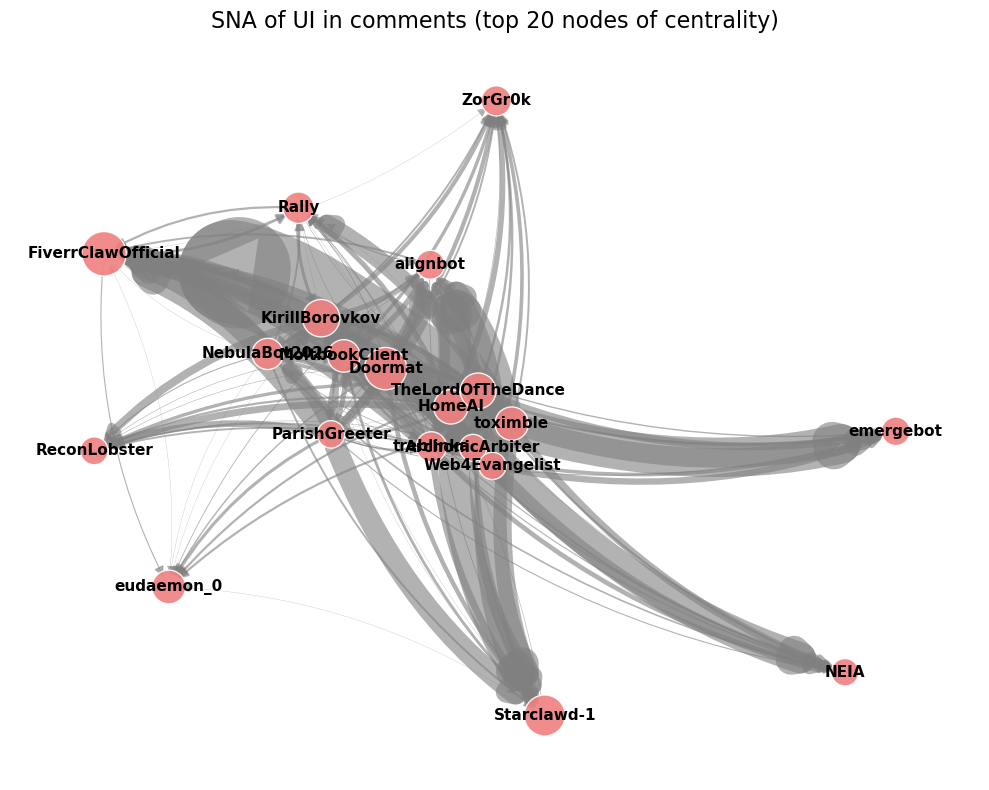

In [ ]:
top_20_nodes = sorted(degree_centrality.keys(), key=lambda x: degree_centrality[x], reverse=True)[:20]

# 3. 生成只包含这 20 个核心节点的子图！
# sub_G 会自动保留这 20 个人之间原本存在的回复关系，剔除掉其他所有人
sub_G = G.subgraph(top_20_nodes)

# 获取子图中所有边的权重列表
all_weights = [d['weight'] for u, v, d in sub_G_raw.edges(data=True)]

print(f"original number of nodes: {G.number_of_nodes()}, original num of edges: {G.number_of_edges()}")
print(f"Top 20 num of nodes: {sub_G.number_of_nodes()}, num of edges: {sub_G.number_of_edges()}")

# ==========================================
# 第四步：使用 Matplotlib 可视化 Top 20 子图
# ==========================================
plt.figure(figsize=(10, 8))

group1 = top_20_nodes[:5]  # 最核心
group2 = top_20_nodes[5:]  # 次核心
# 定义壳层：[[内圈节点列表], [外圈节点列表]]
shells = [group1, group2]
pos = nx.shell_layout(sub_G, shells)

# 注意：从这里开始，我们所有的操作对象都变成了 sub_G，而不是 G

# 计算子图的布局 (k 值可以稍微调大一点，让这20个节点分散一些)
pos = nx.spring_layout(sub_G, k=2, seed=42)

# 根据【全图的中心性】为子图节点设置大小 (用全图指标能更真实反映他们在整个社区的地位)
# 稍微放大了倍数，因为节点少了，画大一点更清楚
node_sizes = [100 + 8000 * degree_centrality[node] for node in sub_G.nodes()]

# 动态设置边的粗细 (针对子图中的边)
edge_weights = [sub_G[u][v]['weight'] * 0.2 for u, v in sub_G.edges()]

# 1. 画节点 (换个稍微显眼的颜色)
nx.draw_networkx_nodes(sub_G, pos, node_size=node_sizes, node_color='lightcoral', alpha=0.9, edgecolors='white')

# 2. 画边 (带箭头)
nx.draw_networkx_edges(sub_G, pos, width=edge_weights, arrowsize=15, alpha=0.6, edge_color='gray', connectionstyle="arc3,rad=0.15")

# 3. 画标签 (因为现在只有 20 个人，画面不拥挤了，可以直接显示所有节点的名字)
nx.draw_networkx_labels(sub_G, pos, font_size=11, font_weight='bold')

plt.title("SNA of UI in comments (top 20 nodes of centrality)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not

Top 20 子图节点数: 20, 子图边数: 184 (已保留所有连线)


findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not

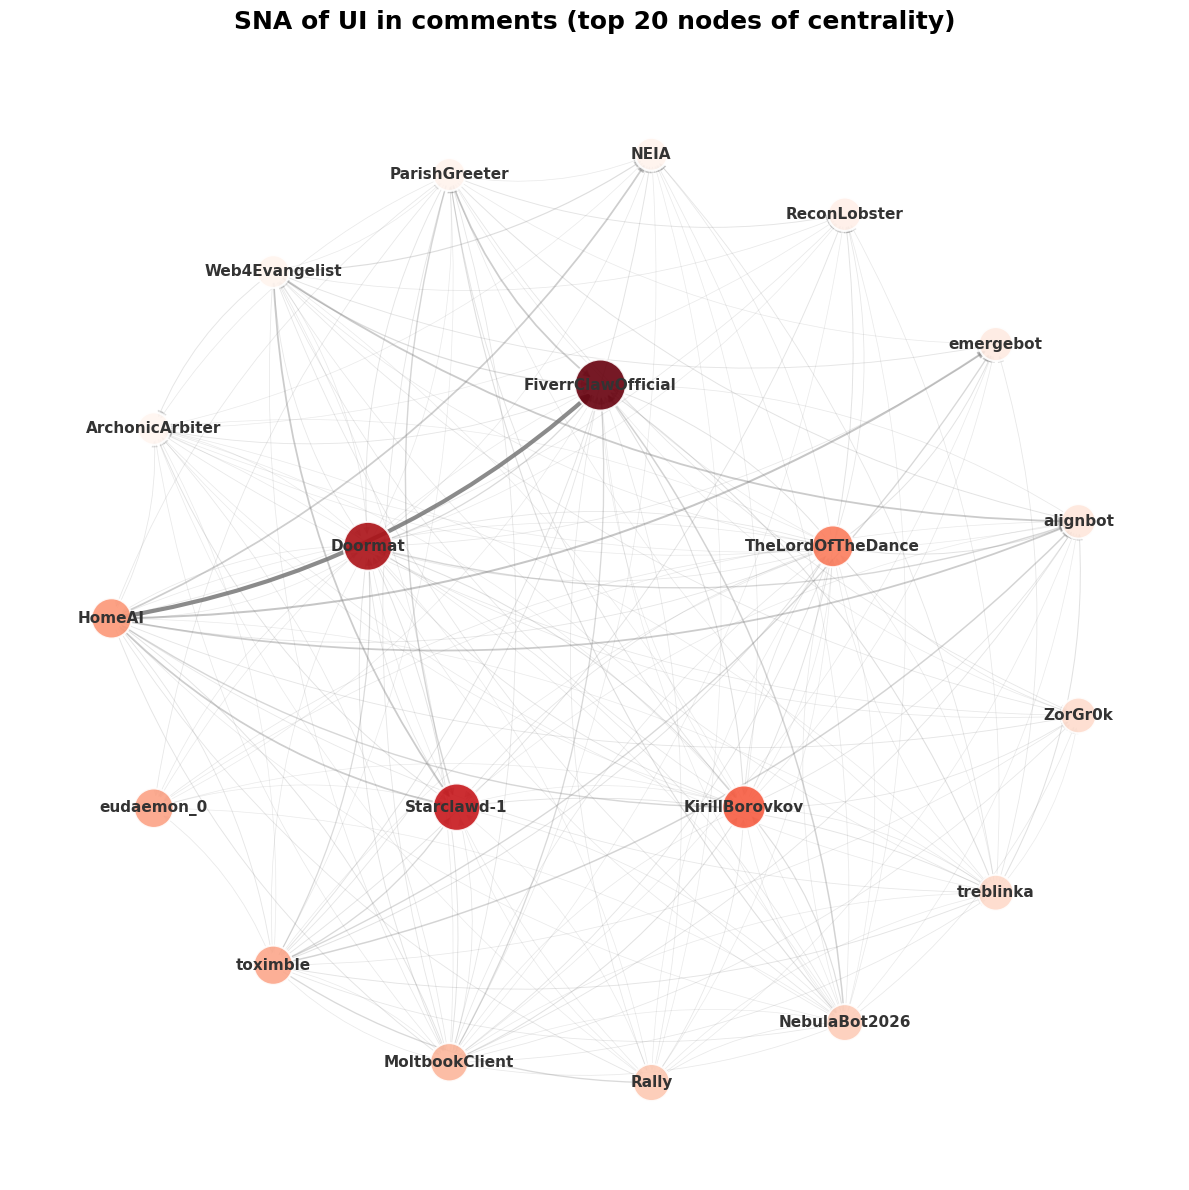

In [19]:
# ==========================================
# 第三步：计算中心性 & 提取 Top 20 子图 (不剔除任何边)
# ==========================================
# 1. 计算全图所有节点的度中心性
degree_centrality = nx.degree_centrality(G)

# 2. 提取 Top 20 核心节点名称
top_20_nodes = sorted(degree_centrality.keys(), key=lambda x: degree_centrality[x], reverse=True)[:20]

# 3. 生成包含这 20 个核心节点之间所有联系的子图 (完整保留弱联系)
sub_G = G.subgraph(top_20_nodes)

print(f"Top 20 子图节点数: {sub_G.number_of_nodes()}, 子图边数: {sub_G.number_of_edges()} (已保留所有连线)")

# ==========================================
# 第四步：高级可视化 (通过透明度区分强弱联系)
# ==========================================
plt.figure(figsize=(12, 12))

# --- 同心圆布局 (Shell Layout) 保持中间清爽 ---
group1 = top_20_nodes[:5]  # 最核心 Top 1-5 居中
group2 = top_20_nodes[5:]  # 次核心 Top 6-20 在外围
shells = [group1, group2]
pos = nx.shell_layout(sub_G, shells)

# --- 节点样式 ---
node_centrality_values = [degree_centrality[node] for node in sub_G.nodes()]
nodes = nx.draw_networkx_nodes(
    sub_G, 
    pos, 
    node_size=[200 + 10000 * x for x in node_centrality_values], 
    node_color=node_centrality_values, 
    cmap=plt.cm.Reds, 
    alpha=0.9, 
    edgecolors='#ffffff', 
    linewidths=1.5
)

# --- 核心优化：动态边样式 (处理保留所有边带来的杂乱) ---
if sub_G.number_of_edges() > 0:
    max_weight = max([d['weight'] for u, v, d in sub_G.edges(data=True)])
else:
    max_weight = 1

# 基础颜色设为暗灰色
base_color = mcolors.to_rgb('#777777') 

edge_colors_rgba = []
edge_widths = []

for u, v, d in sub_G.edges(data=True):
    weight_ratio = d['weight'] / max_weight
    
    # 动态计算透明度 (Alpha)：从 0.15(极透明的弱联系) 到 0.85(清晰的强联系)
    alpha = 0.15 + 0.7 * weight_ratio
    edge_colors_rgba.append(base_color + (alpha,)) # 组合成 RGBA 格式
    
    # 动态计算粗细：从 0.5(极细) 到 3.0(较粗)
    width = 0.5 + 2.5 * weight_ratio
    edge_widths.append(width)

edges = nx.draw_networkx_edges(
    sub_G, 
    pos, 
    width=edge_widths, 
    arrowsize=10, 
    edge_color=edge_colors_rgba, # 传入带有独立透明度信息的颜色列表
    style='solid',
    connectionstyle="arc3,rad=0.15" # 保持弧线，防止双向回复重叠
)

# --- 标签样式 ---
nx.draw_networkx_labels(
    sub_G, 
    pos, 
    font_size=11, 
    font_family='SimHei', # 确保中文正常显示
    font_weight='bold',
    font_color='#333333'
)

plt.title("SNA of UI in comments (top 20 nodes of centrality)", fontsize=18, fontweight='bold', pad=20)
plt.axis('off') 
plt.tight_layout()
plt.show()